# Gene Enrichment and Barcode-Aware Deduplication

The primary objective of this analysis is to identify genomic regions enriched within the targeted small RNA sequencing assay while accounting for potential amplification bias identified during QC analysis.

Because molecular barcodes (`mb`) are embedded within BAM records, enrichment will be evaluated using both:
- raw aligned read counts, and
- barcode-deduplicated molecule counts.

This approach enables separation of true molecular enrichment from potential PCR-driven overrepresentation.

In [1]:
import pysam
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
bam_dir = Path("../data/bam")
bam_files = sorted(bam_dir.glob("*.bam"))

fig_dir = Path("../results/figures")
table_dir = Path("../results/tables")

In [3]:
rows = []

for bam_file in bam_files:

    sample = bam_file.stem
    bam = pysam.AlignmentFile(bam_file, "rb")

    for read in bam.fetch(until_eof=True):

        if read.is_secondary:
            continue

        try:
            barcode = read.get_tag("mb")
        except KeyError:
            barcode = None

        rows.append({
            "sample": sample,
            "chrom": read.reference_name,
            "start": read.reference_start,
            "bin": (read.reference_start // 1000) * 1000,
            "barcode": barcode
        })

enrich_df = pd.DataFrame(rows)

enrich_df.head()

[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample1.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample2.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample3.bam.bai


,sample,chrom,start,bin,barcode
0,sample1,1,859010,859000,AAGAGTCA
1,sample1,1,859010,859000,AAGAGTCA
2,sample1,1,977386,977000,CCGGTTTT
3,sample1,1,978619,978000,GACACGCG
4,sample1,1,978678,978000,AACGGGCC


In [6]:
# Count the number of primary alignments in each genomic bin
# This represents the raw enrichment signal before barcode deduplication
raw_counts = (
    enrich_df
    .groupby(["sample", "chrom", "bin"])
    .size()
    .reset_index(name="raw_read_count")
)

# Count unique barcode-supported molecules in each genomic bin
# Reads with the same sample, chromosome, bin, and mb barcode are counted once
dedup_counts = (
    enrich_df
    .drop_duplicates(["sample", "chrom", "bin", "barcode"])
    .groupby(["sample", "chrom", "bin"])
    .size()
    .reset_index(name="dedup_molecule_count")
)

# Merge raw read counts and barcode-deduplicated molecule counts
# This allows direct comparison of sequencing depth vs estimated molecule abundance
bin_counts = raw_counts.merge(
    dedup_counts,
    on=["sample", "chrom", "bin"],
    how="left"
)

# Estimate amplification redundancy within each genomic bin
# Higher values suggest more reads per unique barcode-supported molecule
bin_counts["reads_per_molecule"] = (
    bin_counts["raw_read_count"] / bin_counts["dedup_molecule_count"]
)

bin_counts.head(20)

,sample,chrom,bin,raw_read_count,dedup_molecule_count,reads_per_molecule
0,sample1,1,859000,2,1,2.000000
1,sample1,1,977000,1,1,1.000000
2,sample1,1,978000,4,3,1.333333
3,sample1,1,3188000,2,1,2.000000
4,sample1,1,3438000,1,1,1.000000
5,sample1,1,7022000,1,1,1.000000
6,sample1,1,8581000,2,1,2.000000
7,sample1,1,8746000,2,1,2.000000
8,sample1,1,9446000,1,1,1.000000
9,sample1,1,15299000,2,1,2.000000


In [7]:
top_bins = (
    bin_counts
    .sort_values(["sample", "raw_read_count"], ascending=[True, False])
    .groupby("sample")
    .head(20)
)

top_bins

,sample,chrom,bin,raw_read_count,dedup_molecule_count,reads_per_molecule
259,sample1,11,69456000,126890,38019,3.337542
681,sample1,19,34890000,114357,30226,3.783398
260,sample1,11,69457000,90014,31801,2.830540
335,sample1,12,52636000,87778,30330,2.894098
937,sample1,20,57484000,55613,22082,2.518477
721,sample1,19,41765000,40644,16366,2.483441
1401,sample1,7,116380000,39808,14891,2.673293
1075,sample1,3,128525000,39575,13170,3.004935
713,sample1,19,41754000,39305,14587,2.694523
720,sample1,19,41763000,35306,13755,2.566776


Deduplication is showing altered enrichment estimates in sample3,  where many highly enriched loci showed extreme reads-per-molecule ratios (>50–100). This suggests that raw sequencing depth alone substantially overestimates true molecular abundance in this sample.

This finding is consistent with the earlier BAM QC results, where sample3 also showed elevated reads per molecular barcode, suggesting increased PCR amplification redundancy or reduced molecular complexity.

Importantly, sample3 still showed enrichment at many of the same genomic loci observed in samples 1 and 2. Therefore, I retained sample3 for downstream analysis, but interpreted its raw read-depth signal cautiously and prioritized barcode-deduplicated molecule counts.

In contrast, samples 1 and 2 demonstrated more moderate amplification redundancy and retained substantially larger numbers of unique barcode-supported molecules across enriched loci.

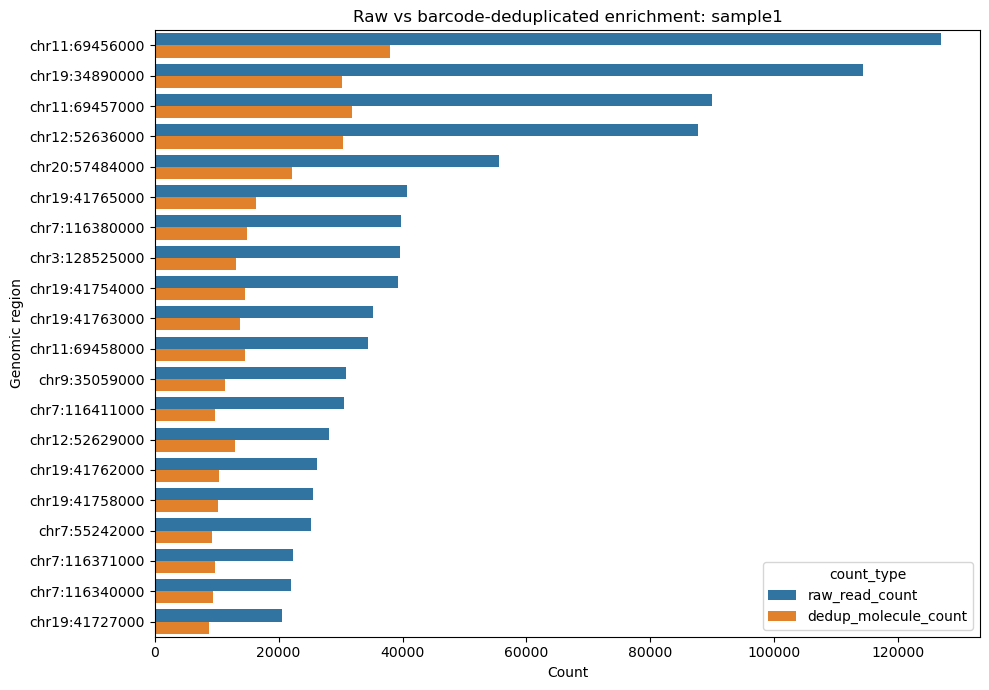

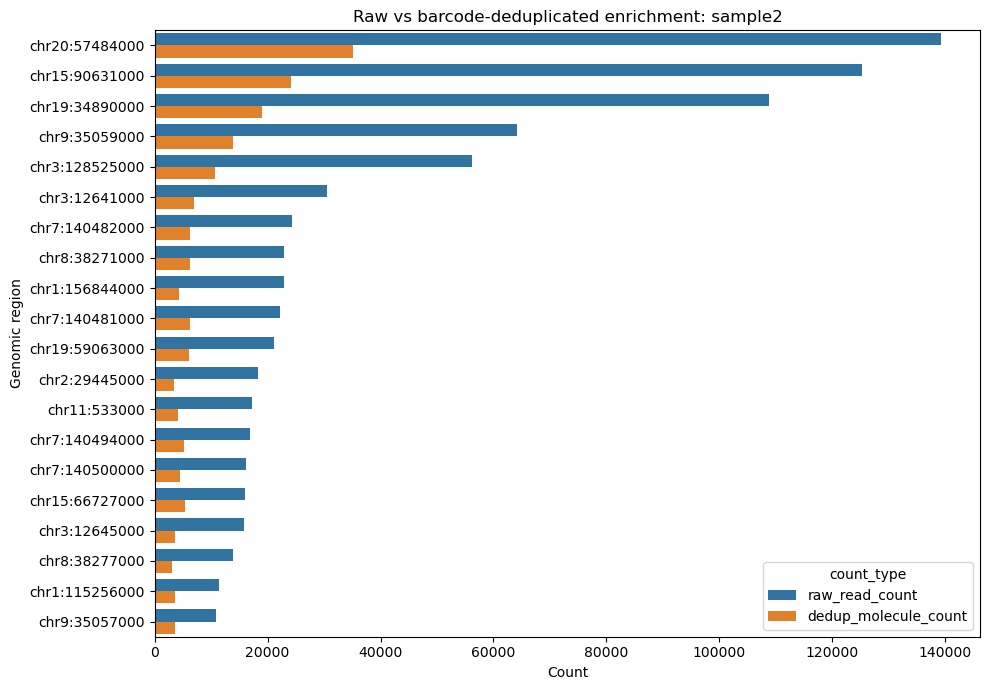

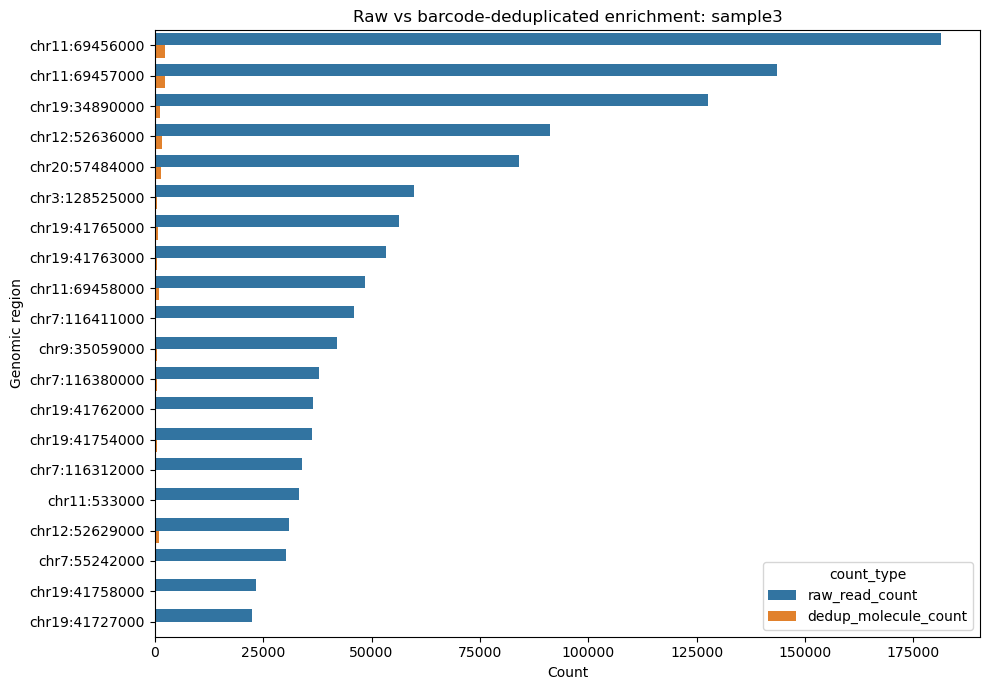

In [9]:
for sample in top_bins["sample"].unique():

    plot_df = top_bins[top_bins["sample"] == sample].copy()

    plot_df["region"] = (
        "chr" + plot_df["chrom"].astype(str) + ":" +
        plot_df["bin"].astype(str)
    )

    plot_df = plot_df.melt(
        id_vars="region",
        value_vars=["raw_read_count", "dedup_molecule_count"],
        var_name="count_type",
        value_name="count"
    )

    plt.figure(figsize=(10, 7))

    sns.barplot(
        data=plot_df,
        x="count",
        y="region",
        hue="count_type"
    )

    plt.title(f"Raw vs barcode-deduplicated enrichment: {sample}")
    plt.xlabel("Count")
    plt.ylabel("Genomic region")

    plt.tight_layout()
    plt.savefig(fig_dir / f"{sample}_top_regions_raw_vs_dedup.png", dpi=300, bbox_inches="tight")
    plt.show()

### Barcode-Aware Enrichment Analysis

Comparison of raw read enrichment and barcode-deduplicated molecule enrichment revealed that the targeted assay reproducibly enriched a shared set of dominant genomic loci across all three samples. Several highly enriched regions were consistently observed across samples, including loci on chromosomes 11, 19, 20, 3, and 7.

However, barcode-aware deduplication substantially altered the interpretation of enrichment magnitude, **particularly in sample3**. 

While sample3 exhibited extremely high raw read counts across multiple enriched loci, deduplicated molecule counts were markedly reduced relative to samples 1 and 2. This indicates that a large fraction of the apparent sequencing depth in sample3 likely derives from repeated amplification of a smaller underlying pool of unique molecules.

In contrast, samples 1 and 2 retained substantially larger numbers of unique barcode-supported molecules after deduplication, suggesting greater molecular complexity and lower amplification redundancy.

These findings demonstrate that molecular barcode information is essential for accurate interpretation of enrichment within this dataset and highlight the importance of distinguishing raw sequencing depth from true molecule-supported abundance.

<
<
<
<
<>>>>>

Now we will observe what bins are shared across samples.

In [10]:
shared_bins = (
    bin_counts
    .groupby(["chrom", "bin"])
    .agg(
        n_samples=("sample", "nunique"),
        total_raw_reads=("raw_read_count", "sum"),
        total_dedup_molecules=("dedup_molecule_count", "sum")
    )
    .reset_index()
)

shared_bins = shared_bins.sort_values(
    "total_dedup_molecules",
    ascending=False
)

shared_bins.head(20)

,chrom,bin,n_samples,total_raw_reads,total_dedup_molecules
2278,20,57484000,3,278829,58623
1727,19,34890000,3,350786,50326
671,11,69456000,3,308751,40638
672,11,69457000,3,234079,34212
856,12,52636000,2,179067,31908
1252,15,90631000,3,147318,29072
3714,9,35059000,3,137153,25640
2601,3,128525000,3,155699,24321
1776,19,41765000,3,97333,17326
673,11,69458000,3,83105,15609


In [11]:
shared_bins["region"] = (
    "chr" + shared_bins["chrom"].astype(str) + ":" +
    shared_bins["bin"].astype(str)
)

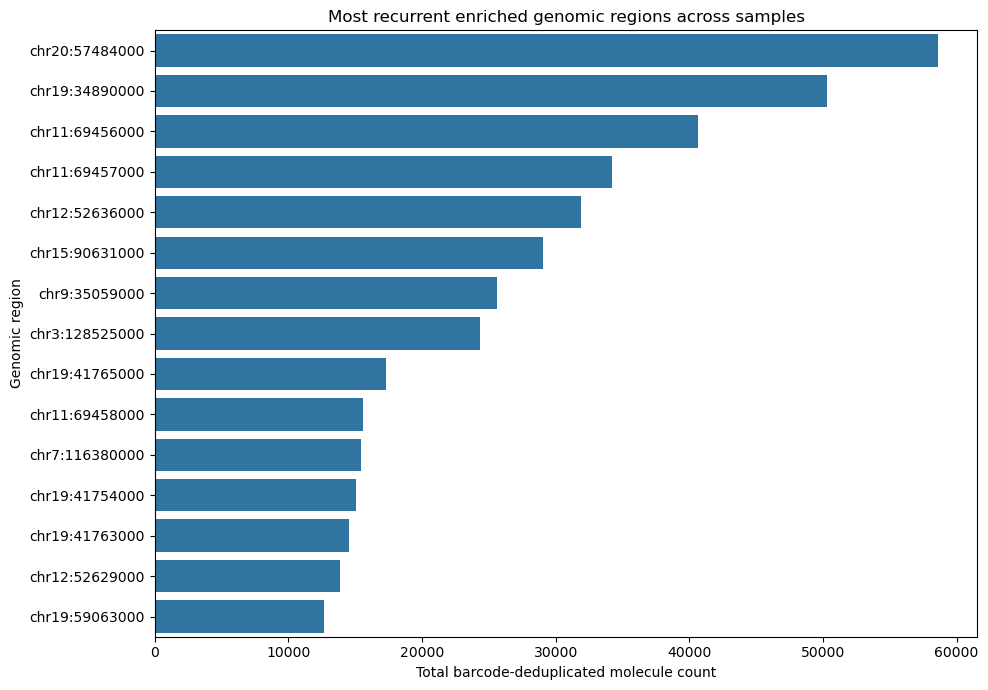

In [12]:
top_shared = shared_bins.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_shared,
    x="total_dedup_molecules",
    y="region"
)

plt.title("Most recurrent enriched genomic regions across samples")
plt.xlabel("Total barcode-deduplicated molecule count")
plt.ylabel("Genomic region")

plt.tight_layout()
plt.savefig(fig_dir / "shared_enriched_regions.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
top_shared = shared_bins.head(30).copy()

top_shared["start"] = top_shared["bin"]
top_shared["end"] = top_shared["bin"] + 999
top_shared["region"] = (
    "chr" + top_shared["chrom"].astype(str) + ":" +
    top_shared["start"].astype(str) + "-" +
    top_shared["end"].astype(str)
)

top_shared = top_shared[
    [
        "chrom",
        "start",
        "end",
        "region",
        "n_samples",
        "total_raw_reads",
        "total_dedup_molecules"
    ]
]

top_shared.to_csv(table_dir / "top_shared_enriched_regions.csv", index=False)

top_shared.head(20)

,chrom,start,end,region,n_samples,total_raw_reads,total_dedup_molecules
2278,20,57484000,57484999,chr20:57484000-57484999,3,278829,58623
1727,19,34890000,34890999,chr19:34890000-34890999,3,350786,50326
671,11,69456000,69456999,chr11:69456000-69456999,3,308751,40638
672,11,69457000,69457999,chr11:69457000-69457999,3,234079,34212
856,12,52636000,52636999,chr12:52636000-52636999,2,179067,31908
1252,15,90631000,90631999,chr15:90631000-90631999,3,147318,29072
3714,9,35059000,35059999,chr9:35059000-35059999,3,137153,25640
2601,3,128525000,128525999,chr3:128525000-128525999,3,155699,24321
1776,19,41765000,41765999,chr19:41765000-41765999,3,97333,17326
673,11,69458000,69458999,chr11:69458000-69458999,3,83105,15609


In [14]:
bed_df = top_shared.copy()

bed_df["chrom"] = "chr" + bed_df["chrom"].astype(str)

bed_df[["chrom", "start", "end", "region"]].to_csv(
    "../results/tables/top_shared_enriched_regions.bed",
    sep="\t",
    header=False,
    index=False
)

### Exporting Recurrent Enriched Regions for Gene Annotation

Because no target BED or gene annotation file was provided with the assignment, I first identified recurrent enriched genomic regions directly from the BAM alignments. The top barcode-deduplicated enriched bins were exported as a BED-style file for downstream gene/transcript annotation against hg19.

In [15]:
gtf_path = Path("../genomes/gencode.v19.annotation.gtf")

gene_rows = []

with open(gtf_path) as f:
    for line in f:
        if line.startswith("#"):
            continue
        
        fields = line.strip().split("\t")
        
        if len(fields) < 9:
            continue
        
        chrom, source, feature, start, end, score, strand, frame, attributes = fields
        
        if feature != "gene":
            continue
        
        gene_name = "."
        gene_type = "."
        gene_id = "."
        
        for item in attributes.split(";"):
            item = item.strip()
            
            if item.startswith("gene_name"):
                gene_name = item.split('"')[1]
            elif item.startswith("gene_type"):
                gene_type = item.split('"')[1]
            elif item.startswith("gene_id"):
                gene_id = item.split('"')[1]
        
        gene_rows.append({
            "chrom": chrom,
            "gene_start": int(start) - 1,
            "gene_end": int(end),
            "gene_name": gene_name,
            "gene_type": gene_type,
            "gene_id": gene_id
        })

genes_df = pd.DataFrame(gene_rows)

genes_df.head()

,chrom,gene_start,gene_end,gene_name,gene_type,gene_id
0,chr1,11868,14412,DDX11L1,pseudogene,ENSG00000223972.4
1,chr1,14362,29806,WASH7P,pseudogene,ENSG00000227232.4
2,chr1,29553,31109,MIR1302-11,lincRNA,ENSG00000243485.2
3,chr1,34553,36081,FAM138A,lincRNA,ENSG00000237613.2
4,chr1,52472,54936,OR4G4P,pseudogene,ENSG00000268020.2


### Gene Annotation of Enriched Regions

we have genes!!!!

The recurrent enriched genomic regions were annotated using GENCODE v19, which is compatible with the hg19/GRCh37 coordinate system used for the aligned BAM files. Each enriched 1 kb genomic bin was intersected with gene-level annotations to identify overlapping genes or transcript classes.


In [16]:
regions_df = top_shared.copy()
regions_df["chrom"] = "chr" + regions_df["chrom"].astype(str)

overlap_rows = []

for _, region in regions_df.iterrows():
    hits = genes_df[
        (genes_df["chrom"] == region["chrom"]) &
        (genes_df["gene_start"] <= region["end"]) &
        (genes_df["gene_end"] >= region["start"])
    ]
    
    for _, gene in hits.iterrows():
        overlap_rows.append({
            "region": region["region"],
            "n_samples": region["n_samples"],
            "total_raw_reads": region["total_raw_reads"],
            "total_dedup_molecules": region["total_dedup_molecules"],
            "gene_name": gene["gene_name"],
            "gene_type": gene["gene_type"],
            "gene_id": gene["gene_id"]
        })

annotated_regions = pd.DataFrame(overlap_rows)

annotated_regions.to_csv(
    table_dir / "top_shared_enriched_regions_gene_annotations.csv",
    index=False
)

annotated_regions.head(30)

,region,n_samples,total_raw_reads,total_dedup_molecules,gene_name,gene_type,gene_id
0,chr20:57484000-57484999,3,278829,58623,GNAS,protein_coding,ENSG00000087460.19
1,chr19:34890000-34890999,3,350786,50326,GPI,protein_coding,ENSG00000105220.10
2,chr19:34890000-34890999,3,350786,50326,RP11-618P17.4,protein_coding,ENSG00000266953.2
3,chr11:69456000-69456999,3,308751,40638,CCND1,protein_coding,ENSG00000110092.3
4,chr11:69457000-69457999,3,234079,34212,CCND1,protein_coding,ENSG00000110092.3
5,chr12:52636000-52636999,2,179067,31908,KRT7,protein_coding,ENSG00000135480.10
6,chr15:90631000-90631999,3,147318,29072,IDH2,protein_coding,ENSG00000182054.5
7,chr9:35059000-35059999,3,137153,25640,VCP,protein_coding,ENSG00000165280.11
8,chr3:128525000-128525999,3,155699,24321,RAB7A,protein_coding,ENSG00000075785.8
9,chr19:41765000-41765999,3,97333,17326,AXL,protein_coding,ENSG00000167601.7


In [17]:
regions_df = top_shared.copy()
regions_df["chrom"] = "chr" + regions_df["chrom"].astype(str)

overlap_rows = []

for _, region in regions_df.iterrows():
    hits = genes_df[
        (genes_df["chrom"] == region["chrom"]) &
        (genes_df["gene_start"] <= region["end"]) &
        (genes_df["gene_end"] >= region["start"])
    ]
    
    for _, gene in hits.iterrows():
        overlap_rows.append({
            "region": region["region"],
            "n_samples": region["n_samples"],
            "total_raw_reads": region["total_raw_reads"],
            "total_dedup_molecules": region["total_dedup_molecules"],
            "gene_name": gene["gene_name"],
            "gene_type": gene["gene_type"],
            "gene_id": gene["gene_id"]
        })

annotated_regions = pd.DataFrame(overlap_rows)

annotated_regions.to_csv(
    table_dir / "top_shared_enriched_regions_gene_annotations.csv",
    index=False
)

annotated_regions.head(30)

,region,n_samples,total_raw_reads,total_dedup_molecules,gene_name,gene_type,gene_id
0,chr20:57484000-57484999,3,278829,58623,GNAS,protein_coding,ENSG00000087460.19
1,chr19:34890000-34890999,3,350786,50326,GPI,protein_coding,ENSG00000105220.10
2,chr19:34890000-34890999,3,350786,50326,RP11-618P17.4,protein_coding,ENSG00000266953.2
3,chr11:69456000-69456999,3,308751,40638,CCND1,protein_coding,ENSG00000110092.3
4,chr11:69457000-69457999,3,234079,34212,CCND1,protein_coding,ENSG00000110092.3
5,chr12:52636000-52636999,2,179067,31908,KRT7,protein_coding,ENSG00000135480.10
6,chr15:90631000-90631999,3,147318,29072,IDH2,protein_coding,ENSG00000182054.5
7,chr9:35059000-35059999,3,137153,25640,VCP,protein_coding,ENSG00000165280.11
8,chr3:128525000-128525999,3,155699,24321,RAB7A,protein_coding,ENSG00000075785.8
9,chr19:41765000-41765999,3,97333,17326,AXL,protein_coding,ENSG00000167601.7


### Gene-Level Annotation of Enriched Regions

Annotation of recurrent enriched genomic bins using GENCODE v19 identified a focused set of protein-coding genes repeatedly enriched across samples. The most enriched regions overlapped cancer-relevant genes including **GNAS, CCND1, IDH2, AXL, MET, EGFR, FGFR1, BRAF, HRAS, RAF1, MAP2K1, and RAB7A**.

Several genes appeared across multiple adjacent enriched bins, including **CCND1**, **AXL**, and **MET**, consistent with localized targeted coverage across extended gene regions rather than isolated single-bin artifacts.

The enriched gene set strongly suggests that the assay targets clinically relevant cancer-associated loci. Importantly, enrichment estimates were evaluated using barcode-deduplicated molecule counts to reduce PCR-driven inflation, particularly in sample3.

In [18]:
gene_enrichment = (
    annotated_regions
    .groupby(["gene_name", "gene_type"])
    .agg(
        n_regions=("region", "nunique"),
        n_samples=("n_samples", "max"),
        total_raw_reads=("total_raw_reads", "sum"),
        total_dedup_molecules=("total_dedup_molecules", "sum")
    )
    .reset_index()
)

gene_enrichment["reads_per_molecule"] = (
    gene_enrichment["total_raw_reads"] / gene_enrichment["total_dedup_molecules"]
)

gene_enrichment = gene_enrichment.sort_values(
    "total_dedup_molecules",
    ascending=False
)

gene_enrichment.to_csv(
    table_dir / "gene_level_enrichment_summary.csv",
    index=False
)

gene_enrichment.head(20)

,gene_name,gene_type,n_regions,n_samples,total_raw_reads,total_dedup_molecules,reads_per_molecule
2,CCND1,protein_coding,3,3,625935,90459,6.919544
0,AXL,protein_coding,6,3,417265,77404,5.390742
7,GNAS,protein_coding,2,3,299421,69477,4.309642
13,MET,protein_coding,5,3,290156,53704,5.402875
16,RP11-618P17.4,protein_coding,1,3,350786,50326,6.970274
8,GPI,protein_coding,1,3,350786,50326,6.970274
11,KRT7,protein_coding,2,3,238169,45779,5.202582
10,IDH2,protein_coding,1,3,147318,29072,5.067350
17,VCP,protein_coding,1,3,137153,25640,5.349181
14,RAB7A,protein_coding,1,3,155699,24321,6.401834


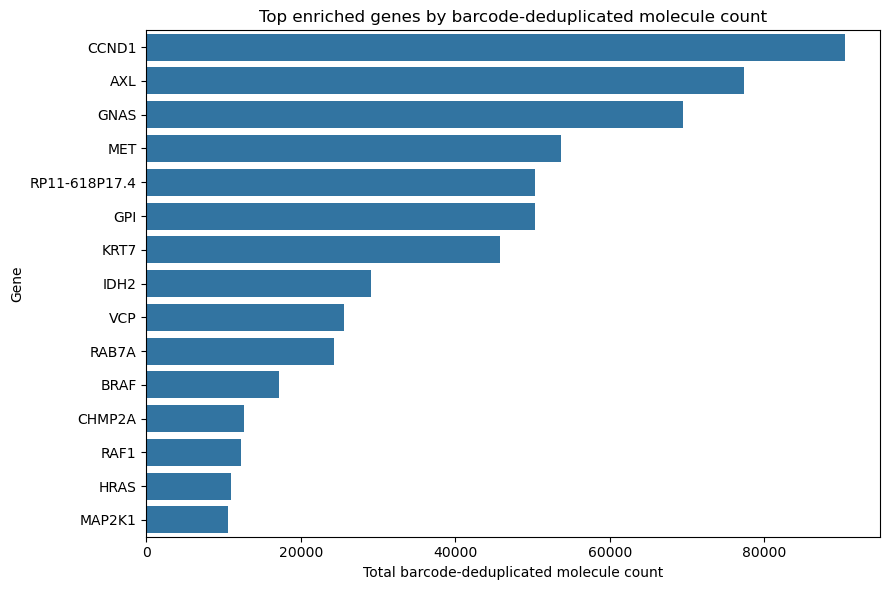

In [19]:
top_genes = gene_enrichment.head(15)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_genes,
    x="total_dedup_molecules",
    y="gene_name"
)

plt.title("Top enriched genes by barcode-deduplicated molecule count")
plt.xlabel("Total barcode-deduplicated molecule count")
plt.ylabel("Gene")

plt.tight_layout()
plt.savefig(fig_dir / "top_enriched_genes_dedup_counts.png", dpi=300, bbox_inches="tight")
plt.show()

### Gene-Level Enrichment Summary

After annotating recurrent enriched genomic bins, I collapsed enrichment estimates to the gene level. Genes were ranked by total barcode-deduplicated molecule counts rather than raw read counts to reduce the influence of PCR amplification.

This produced a focused set of enriched genes, including several cancer-relevant targets such as **GNAS, CCND1, AXL, MET, EGFR, FGFR1, BRAF, HRAS, RAF1, MAP2K1, and IDH2**.

In [ ]:
gene_compare = gene_enrichment.copy() # comparing raw read counts vs deduplicated molecule counts for top enriched genes

gene_compare["raw_rank"] = gene_compare["total_raw_reads"].rank(
    ascending=False,
    method="min"
)

gene_compare["dedup_rank"] = gene_compare["total_dedup_molecules"].rank(
    ascending=False,
    method="min"
)

gene_compare["rank_shift"] = gene_compare["raw_rank"] - gene_compare["dedup_rank"]

gene_compare.sort_values("dedup_rank").head(20)

,gene_name,gene_type,n_regions,n_samples,total_raw_reads,total_dedup_molecules,reads_per_molecule,raw_rank,dedup_rank,rank_shift
2,CCND1,protein_coding,3,3,625935,90459,6.919544,1.0,1.0,0.0
0,AXL,protein_coding,6,3,417265,77404,5.390742,2.0,2.0,0.0
7,GNAS,protein_coding,2,3,299421,69477,4.309642,5.0,3.0,2.0
13,MET,protein_coding,5,3,290156,53704,5.402875,6.0,4.0,2.0
16,RP11-618P17.4,protein_coding,1,3,350786,50326,6.970274,3.0,5.0,-2.0
8,GPI,protein_coding,1,3,350786,50326,6.970274,3.0,5.0,-2.0
11,KRT7,protein_coding,2,3,238169,45779,5.202582,7.0,7.0,0.0
10,IDH2,protein_coding,1,3,147318,29072,5.067350,9.0,8.0,1.0
17,VCP,protein_coding,1,3,137153,25640,5.349181,10.0,9.0,1.0
14,RAB7A,protein_coding,1,3,155699,24321,6.401834,8.0,10.0,-2.0


The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


In [21]:
gene_compare.to_csv(
    table_dir / "gene_level_raw_vs_dedup_rank_comparison.csv",
    index=False
)

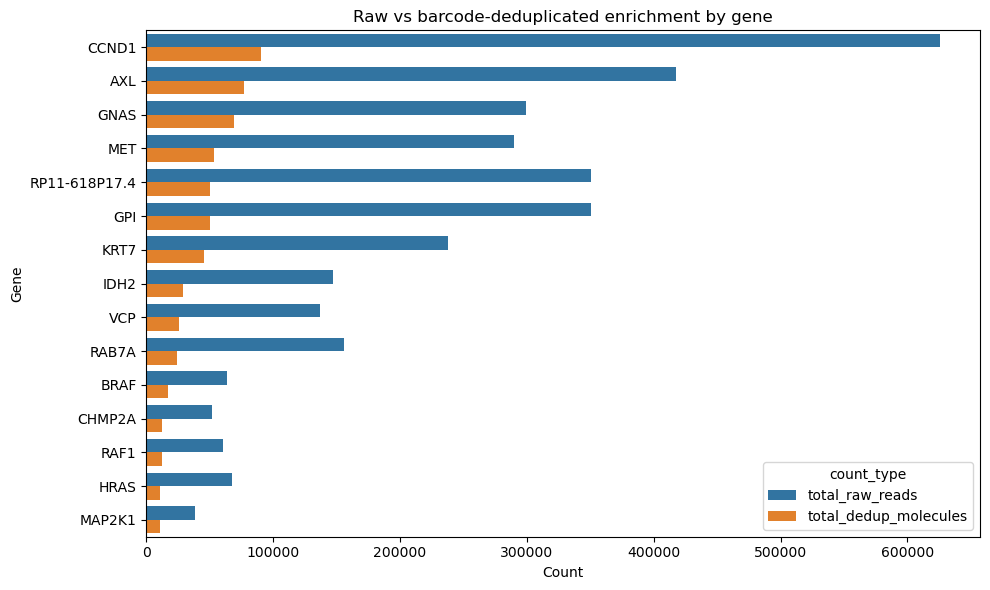

In [22]:
top_compare = gene_compare.sort_values("dedup_rank").head(15)

plot_df = top_compare.melt(
    id_vars="gene_name",
    value_vars=["total_raw_reads", "total_dedup_molecules"],
    var_name="count_type",
    value_name="count"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x="count",
    y="gene_name",
    hue="count_type"
)

plt.title("Raw vs barcode-deduplicated enrichment by gene")
plt.xlabel("Count")
plt.ylabel("Gene")

plt.tight_layout()
plt.savefig(fig_dir / "gene_raw_vs_dedup_enrichment.png", dpi=300, bbox_inches="tight")
plt.show()

### Raw vs Barcode-Deduplicated Gene Enrichment

I compared gene-level enrichment using raw read counts and barcode-deduplicated molecule counts. This comparison highlights genes where apparent enrichment may be inflated by repeated amplification of the same barcode-supported molecules.

Genes were prioritized using barcode-deduplicated molecule counts because this better approximates unique molecular abundance than raw sequencing depth alone.

Im curious about what genes were specifically enriched for sample 3, So I will plot per sample gene enrichment.

In [24]:
# Annotate sample-specific top bins instead of collapsed shared bins
regions_df = top_bins.copy()

regions_df["start"] = regions_df["bin"]
regions_df["end"] = regions_df["bin"] + 999
regions_df["region"] = (
    "chr" + regions_df["chrom"].astype(str) + ":" +
    regions_df["start"].astype(str) + "-" +
    regions_df["end"].astype(str)
)

regions_df["chrom"] = "chr" + regions_df["chrom"].astype(str)

overlap_rows = []

for _, region in regions_df.iterrows():
    hits = genes_df[
        (genes_df["chrom"] == region["chrom"]) &
        (genes_df["gene_start"] <= region["end"]) &
        (genes_df["gene_end"] >= region["start"])
    ]
    
    for _, gene in hits.iterrows():
        overlap_rows.append({
            "sample": region["sample"],
            "region": region["region"],
            "raw_read_count": region["raw_read_count"],
            "dedup_molecule_count": region["dedup_molecule_count"],
            "reads_per_molecule": region["reads_per_molecule"],
            "gene_name": gene["gene_name"],
            "gene_type": gene["gene_type"]
        })

sample_annotated_regions = pd.DataFrame(overlap_rows)

sample_annotated_regions.head()

,sample,region,raw_read_count,dedup_molecule_count,reads_per_molecule,gene_name,gene_type
0,sample1,chr11:69456000-69456999,126890,38019,3.337542,CCND1,protein_coding
1,sample1,chr19:34890000-34890999,114357,30226,3.783398,GPI,protein_coding
2,sample1,chr19:34890000-34890999,114357,30226,3.783398,RP11-618P17.4,protein_coding
3,sample1,chr11:69457000-69457999,90014,31801,2.830540,CCND1,protein_coding
4,sample1,chr12:52636000-52636999,87778,30330,2.894098,KRT7,protein_coding


In [25]:
sample_gene_enrichment = (
    sample_annotated_regions
    .groupby(["sample", "gene_name", "gene_type"])
    .agg(
        total_raw_reads=("raw_read_count", "sum"),
        total_dedup_molecules=("dedup_molecule_count", "sum")
    )
    .reset_index()
)

sample_gene_enrichment["reads_per_molecule"] = (
    sample_gene_enrichment["total_raw_reads"] /
    sample_gene_enrichment["total_dedup_molecules"]
)

sample_gene_enrichment = sample_gene_enrichment.sort_values(
    ["sample", "total_dedup_molecules"],
    ascending=[True, False]
)

sample_gene_enrichment.to_csv(
    table_dir / "sample_gene_level_enrichment_summary.csv",
    index=False
)

sample_gene_enrichment.head(30)

,sample,gene_name,gene_type,total_raw_reads,total_dedup_molecules,reads_per_molecule
1,sample1,CCND1,protein_coding,251290,84445,2.975783
0,sample1,AXL,protein_coding,187483,74067,2.531262
7,sample1,MET,protein_coding,114528,43685,2.621678
6,sample1,KRT7,protein_coding,115902,43223,2.681489
5,sample1,GPI,protein_coding,114357,30226,3.783398
9,sample1,RP11-618P17.4,protein_coding,114357,30226,3.783398
4,sample1,GNAS,protein_coding,55613,22082,2.518477
8,sample1,RAB7A,protein_coding,39575,13170,3.004935
10,sample1,VCP,protein_coding,30903,11337,2.725853
3,sample1,EGFR,protein_coding,25219,9305,2.710263


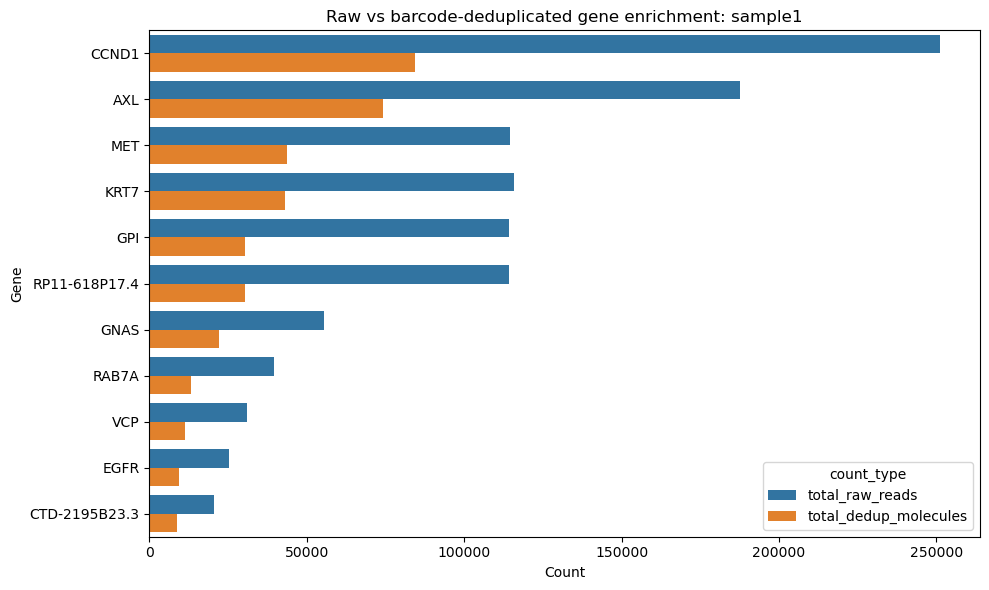

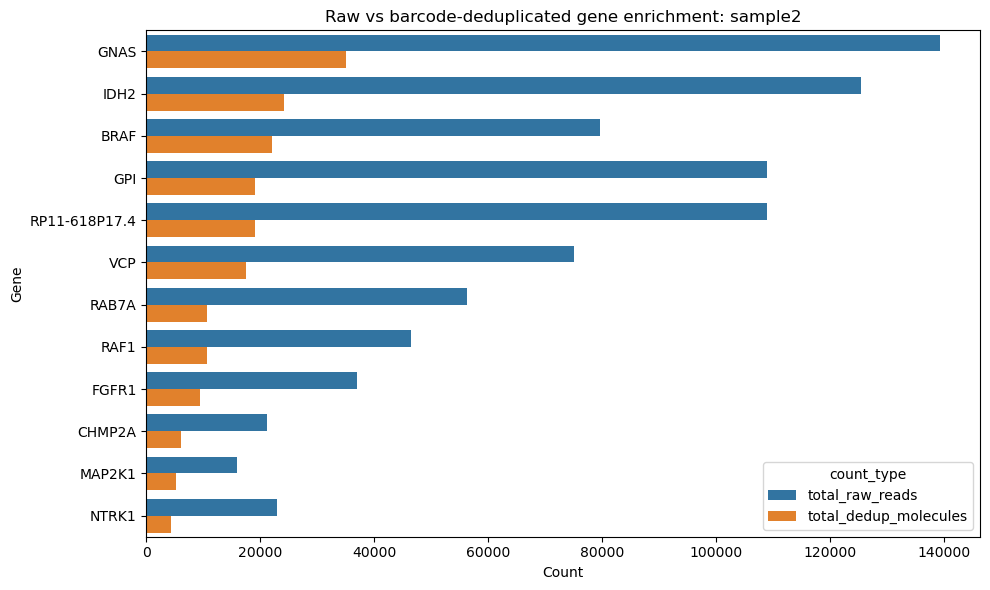

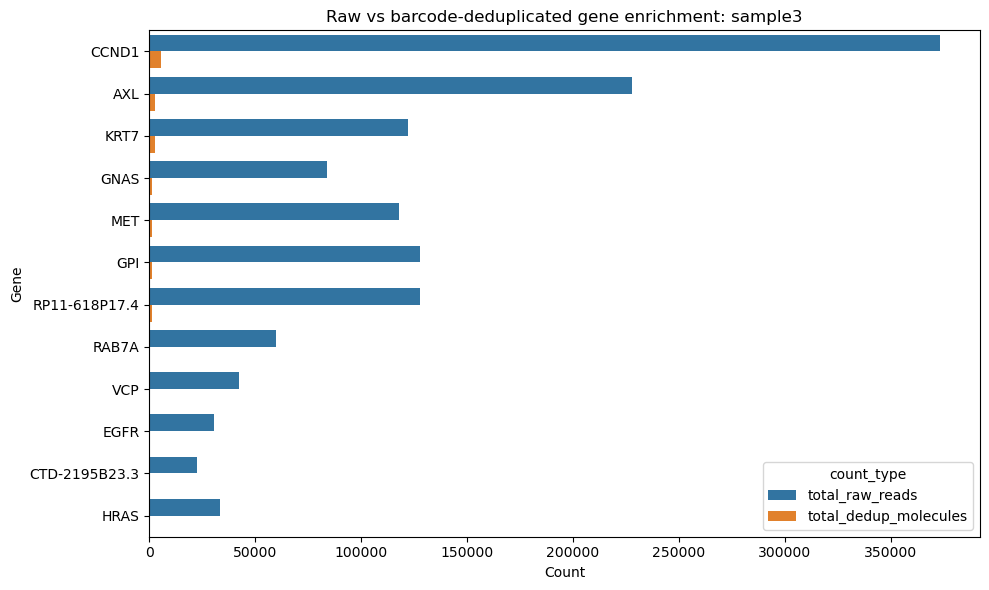

In [26]:
for sample in sample_gene_enrichment["sample"].unique():

    top_sample_genes = (
        sample_gene_enrichment[
            sample_gene_enrichment["sample"] == sample
        ]
        .sort_values("total_dedup_molecules", ascending=False)
        .head(12)
    )

    plot_df = top_sample_genes.melt(
        id_vars="gene_name",
        value_vars=["total_raw_reads", "total_dedup_molecules"],
        var_name="count_type",
        value_name="count"
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=plot_df,
        x="count",
        y="gene_name",
        hue="count_type"
    )

    plt.title(f"Raw vs barcode-deduplicated gene enrichment: {sample}")
    plt.xlabel("Count")
    plt.ylabel("Gene")

    plt.tight_layout()
    plt.savefig(
        fig_dir / f"{sample}_gene_raw_vs_dedup_enrichment.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

Interestingly, enrichment patterns were not identical across samples. For example, Cyclin D1 **CCND1** represented one of the dominant enriched loci in samples 1 and 3 but was not strongly enriched in sample2. In contrast, sample2 showed relatively stronger enrichment for genes including **GNAS, IDH2, BRAF, FGFR1, and RAF1**. Very interesting.

These findings suggest that the samples may not represent simple technical replicates and could instead reflect differences in target composition, biological content, or enrichment efficiency across libraries.

#### Final analysis for this notebook is the amplification skewing. I want to see which genes are most amplification-skewed.

In [27]:
sample_gene_enrichment["reads_per_molecule"] = (
    sample_gene_enrichment["total_raw_reads"] /
    sample_gene_enrichment["total_dedup_molecules"]
)

sample_gene_enrichment = sample_gene_enrichment.sort_values(
    "reads_per_molecule",
    ascending=False
)

sample_gene_enrichment.head(20)

,sample,gene_name,gene_type,total_raw_reads,total_dedup_molecules,reads_per_molecule
35,sample3,RAB7A,protein_coding,59896,494,121.246964
32,sample3,HRAS,protein_coding,33188,277,119.812274
31,sample3,GPI,protein_coding,127571,1109,115.032462
36,sample3,RP11-618P17.4,protein_coding,127571,1109,115.032462
34,sample3,MET,protein_coding,117996,1116,105.731183
37,sample3,VCP,protein_coding,42118,418,100.760766
29,sample3,EGFR,protein_coding,30350,347,87.463977
26,sample3,AXL,protein_coding,227972,2773,82.211323
28,sample3,CTD-2195B23.3,antisense,22349,299,74.745819
27,sample3,CCND1,protein_coding,373488,5583,66.897367


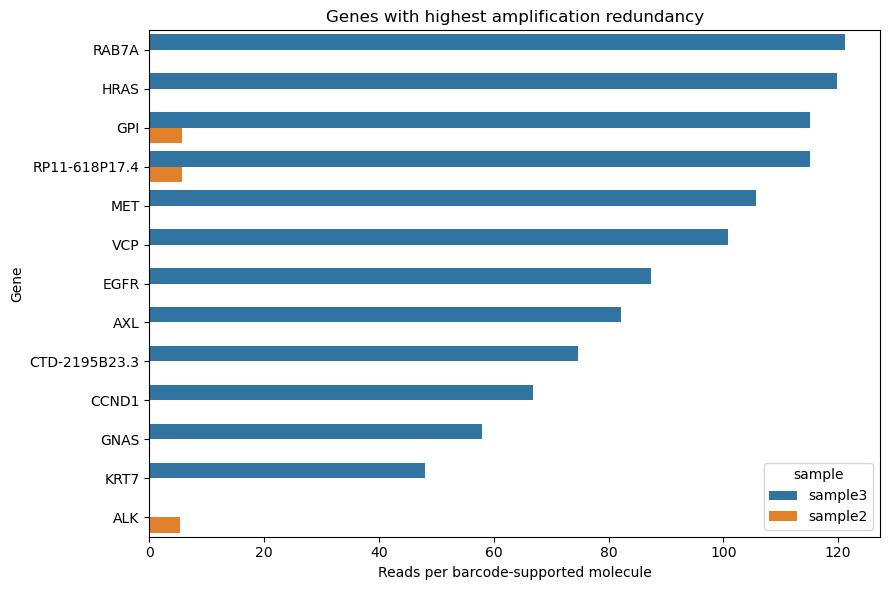

In [28]:
top_skew = sample_gene_enrichment.head(15)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_skew,
    x="reads_per_molecule",
    y="gene_name",
    hue="sample"
)

plt.title("Genes with highest amplification redundancy")
plt.xlabel("Reads per barcode-supported molecule")
plt.ylabel("Gene")

plt.tight_layout()
plt.savefig(
    fig_dir / "gene_amplification_redundancy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Amplification Redundancy Analysis

Gene-level amplification redundancy analysis demonstrated substantial differences between samples. Sample3 exhibited extreme reads-per-molecule ratios across multiple enriched genes, frequently exceeding 50–100 reads per barcode-supported molecule. This strongly suggests reduced molecular complexity and substantial amplification redundancy within this sample.

Importantly, amplification skew was not uniform across genes. Loci including **RAB7A, HRAS, MET, VCP, EGFR, and AXL** showed particularly elevated redundancy within sample3, indicating that some targeted regions were disproportionately amplified relative to others.

In contrast, samples 1 and 2 generally demonstrated substantially lower amplification redundancy and retained larger numbers of unique barcode-supported molecules, supporting more reliable estimation of molecular abundance.

Now we will move to varian analysis.